# **Libraries**

each library covers one job — sklearn for the classical baseline and metrics, gensim for Word2Vec, tensorflow.keras for the neural nets. Setting SEED everywhere makes your results reproducible, which matters when you're comparing five models against each other.

In [1]:
import numpy as np
import pandas as pd
import re
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Dense, Dropout,
                                      Bidirectional, GRU, SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import gensim
from gensim.models import Word2Vec

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# **Load Data**

Keras' IMDb dataset stores reviews as integer sequences (each word replaced by a frequency-rank ID) — great for neural nets, useless for TF-IDF/Word2Vec which need real words. So we decode the integers back into text using the dataset's own word index, and store everything in two DataFrames.

In [2]:
VOCAB_SIZE = 10000 

(x_train_seq, y_train), (x_test_seq, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

word_index = imdb.get_word_index()
index_to_word = {idx + 3: word for word, idx in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"
index_to_word[3] = "<UNUSED>"

def decode_review(seq):
    return " ".join(index_to_word.get(i, "?") for i in seq)

train_texts = [decode_review(seq) for seq in x_train_seq]
test_texts  = [decode_review(seq) for seq in x_test_seq]

df_train = pd.DataFrame({"review": train_texts, "sentiment": y_train})
df_test  = pd.DataFrame({"review": test_texts,  "sentiment": y_test})

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (25000, 2)
Test shape : (25000, 2)


# ***Preprocessing***

Before building anything, I check the data is clean and balanced. Balanced means about half the reviews are positive and half negative — if it wasn't balanced, accuracy alone could lie to us (a model that always says 'positive' would still look good)."



In [3]:
print("Missing values in train:\n", df_train.isnull().sum())
print()
print("Class distribution (train):")
print(df_train['sentiment'].value_counts(normalize=True))

print("\n--- 5 RAW reviews ---")
for i in range(5):
    label = "Positive" if df_train['sentiment'][i] == 1 else "Negative"
    print(f"[{label}] {df_train['review'][i][:300]}...\n")

Missing values in train:
 review       0
sentiment    0
dtype: int64

Class distribution (train):
sentiment
1    0.5
0    0.5
Name: proportion, dtype: float64

--- 5 RAW reviews ---
[Positive] <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the...

[Negative] <START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is co...

[Negative] <START> this has to be one of the worst films of the 1990s when my friends i were watching this film being the target audience it was aimed at we just sat watched the first ha

***Cleaning***

Real text has junk in it — capital letters, HTML tags, random symbols. I remove all of that and make everything lowercase so 'Great' and 'great' count as the same word instead of two different ones.

In [4]:
#Cleaning
def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r"<.*?>", " ", text)            # remove HTML tags
    text = re.sub(r"[^a-z0-9'\s]", " ", text)     # remove punctuation/symbols
    text = re.sub(r"\s+", " ", text).strip()      # normalize extra spaces
    return text

df_train['clean_review'] = df_train['review'].apply(clean_text)
df_test['clean_review']  = df_test['review'].apply(clean_text)

print("--- Before vs After cleaning (5 examples) ---")
for i in range(5):
    print("RAW  :", df_train['review'][i][:150])
    print("CLEAN:", df_train['clean_review'][i][:150])
    print("-" * 80)

--- Before vs After cleaning (5 examples) ---
RAW  : <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine
CLEAN: this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being t
--------------------------------------------------------------------------------
RAW  : <START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i
CLEAN: big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen
--------------------------------------------------------------------------------
RAW  : <START> this has to be one of the worst films of the 1990s when my friends i were watching this film being the target audience it was aimed at we just
CL

***Tokenization***

Tokenizing means cutting a sentence into separate words. I then check how long reviews usually are, so I know how much text to keep for the models later — this is why I picked 300 words as my cutoff

Average length: 224.0 words | Max length: 2194 words
95th percentile: 568 words


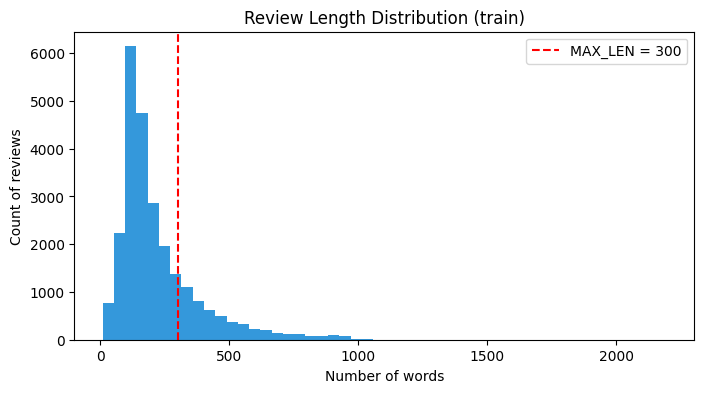

In [5]:
#tokenization
df_train['tokens'] = df_train['clean_review'].apply(str.split)
df_test['tokens']  = df_test['clean_review'].apply(str.split)

lengths = df_train['tokens'].apply(len)
print(f"Average length: {lengths.mean():.1f} words | Max length: {lengths.max()} words")
print(f"95th percentile: {lengths.quantile(0.95):.0f} words")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color='#3498db')
plt.axvline(300, color='red', linestyle='--', label='MAX_LEN = 300')
plt.title("Review Length Distribution (train)")
plt.xlabel("Number of words"); plt.ylabel("Count of reviews")
plt.legend(); plt.show()

***padding***

Neural networks need every input to be the same length. Short reviews get filled with zeros (padding); long ones get cut off (truncating) at 300 words

In [6]:
#padding
MAX_LEN = 300  
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<UNK>")
tokenizer.fit_on_texts(df_train['clean_review'])

X_train_seq = tokenizer.texts_to_sequences(df_train['clean_review'])
X_test_seq  = tokenizer.texts_to_sequences(df_test['clean_review'])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train_arr = df_train['sentiment'].values
y_test_arr  = df_test['sentiment'].values

print("Padded train shape:", X_train_pad.shape)
print("Padded test shape :", X_test_pad.shape)

Padded train shape: (25000, 300)
Padded test shape : (25000, 300)


***spliting***

I split my training data again into a smaller training set and a validation set, so I can check during training whether the model is learning well or starting to memorize instead of learning.

In [7]:
#Spliting
from sklearn.model_selection import train_test_split

X_tr_pad, X_val_pad, y_tr, y_val = train_test_split(
    X_train_pad, y_train_arr, test_size=0.2, random_state=SEED, stratify=y_train_arr
)

print("Train:", X_tr_pad.shape, " Val:", X_val_pad.shape)

Train: (20000, 300)  Val: (5000, 300)


# ***TF-IDF Baseline***

**What TF-IDF represents:**

TF-IDF gives every word a score. A word gets a high score if it shows up a lot in one review but not in most other reviews — that means it's probably important for telling reviews apart. Common words like 'the' or 'movie' get low scores because they're everywhere

Accuracy 0.8947 | Precision 0.8913 | Recall 0.8990 | F1 0.8951


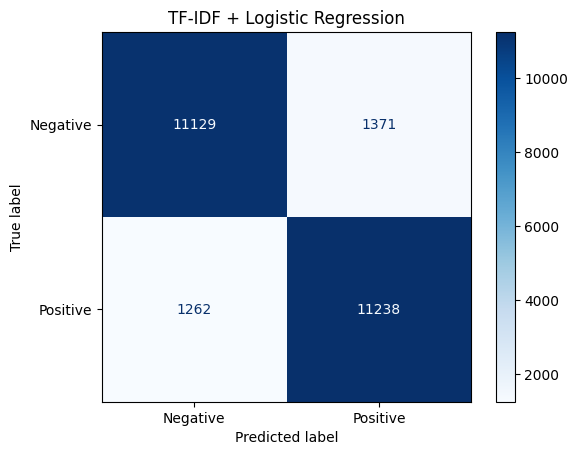

In [8]:
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))  # 🔧 15000 was 10000
X_train_tfidf = tfidf.fit_transform(df_train['clean_review'])
X_test_tfidf  = tfidf.transform(df_test['clean_review'])

log_reg = LogisticRegression(max_iter=1000, C=1.0)
log_reg.fit(X_train_tfidf, y_train_arr)

y_pred_tfidf = log_reg.predict(X_test_tfidf)

acc_tfidf  = accuracy_score(y_test_arr, y_pred_tfidf)
prec_tfidf = precision_score(y_test_arr, y_pred_tfidf)
rec_tfidf  = recall_score(y_test_arr, y_pred_tfidf)
f1_tfidf   = f1_score(y_test_arr, y_pred_tfidf)
print(f"Accuracy {acc_tfidf:.4f} | Precision {prec_tfidf:.4f} | Recall {rec_tfidf:.4f} | F1 {f1_tfidf:.4f}")

cm = confusion_matrix(y_test_arr, y_pred_tfidf)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(cmap="Blues")
plt.title("TF-IDF + Logistic Regression"); plt.show()

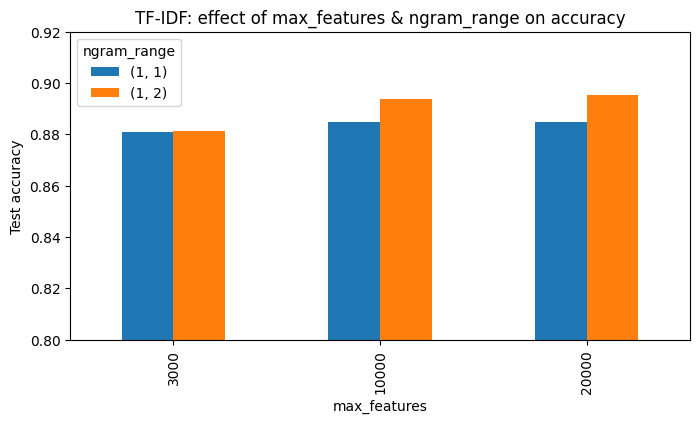

,max_features,ngram_range,accuracy
0,3000,"(1, 1)",0.88080
1,3000,"(1, 2)",0.88140
2,10000,"(1, 1)",0.88472
3,10000,"(1, 2)",0.89392
4,20000,"(1, 1)",0.88472
5,20000,"(1, 2)",0.89544


In [9]:
results = []
for max_feat in [3000, 10000, 20000]:
    for ngram in [(1,1), (1,2)]:
        vec = TfidfVectorizer(max_features=max_feat, ngram_range=ngram)
        Xtr = vec.fit_transform(df_train['clean_review'])
        Xte = vec.transform(df_test['clean_review'])
        clf = LogisticRegression(max_iter=1000).fit(Xtr, y_train_arr)
        acc = accuracy_score(y_test_arr, clf.predict(Xte))
        results.append({"max_features": max_feat, "ngram_range": str(ngram), "accuracy": acc})

sweep_df = pd.DataFrame(results)
pivot = sweep_df.pivot(index="max_features", columns="ngram_range", values="accuracy")
pivot.plot(kind='bar', figsize=(8,4))
plt.title("TF-IDF: effect of max_features & ngram_range on accuracy")
plt.ylabel("Test accuracy"); plt.ylim(0.8, 0.92); plt.show()
sweep_df

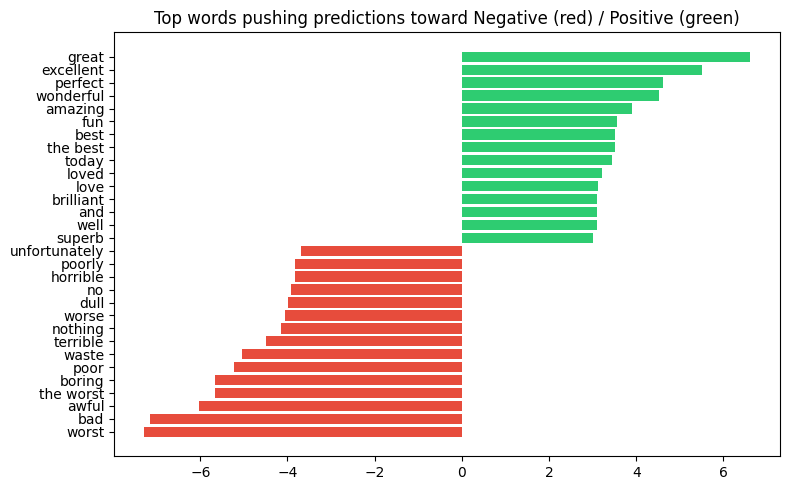

In [10]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = log_reg.coef_[0]
top_pos = feature_names[np.argsort(coefs)[-15:]]
top_neg = feature_names[np.argsort(coefs)[:15]]

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(list(top_neg) + list(top_pos),
        list(np.sort(coefs)[:15]) + list(np.sort(coefs)[-15:]),
        color=['#e74c3c']*15 + ['#2ecc71']*15)
ax.set_title("Top words pushing predictions toward Negative (red) / Positive (green)")
plt.tight_layout(); plt.show()

I tested different settings (vocabulary size, single words vs. word pairs) to see which gives the best accuracy — the chart shows word pairs (like 'not good') help a bit

# ***Word2Vec***

Word2Vec doesn't just count words like TF-IDF — it learns what words mean by looking at which words appear near each other. That's why 'great' ends up close to 'fantastic' and 'wonderful' — the model learned they're used in similar ways.

In [11]:
w2v_model = Word2Vec(
    sentences=df_train['tokens'].tolist(),
    vector_size=128,  
    window=5, min_count=5, workers=4, epochs=10, seed=SEED
)
print("Vocabulary size:", len(w2v_model.wv.index_to_key))

for w in ["great", "terrible", "movie", "boring"]:
    if w in w2v_model.wv:
        print(f"\nMost similar to '{w}':")
        for word, score in w2v_model.wv.most_similar(w, topn=5):
            print(f"   {word}: {score:.3f}")

Vocabulary size: 9988

Most similar to 'great':
   wonderful: 0.765
   fantastic: 0.747
   good: 0.738
   fine: 0.719
   terrific: 0.679

Most similar to 'terrible':
   horrible: 0.874
   awful: 0.809
   horrendous: 0.763
   dreadful: 0.737
   atrocious: 0.726

Most similar to 'movie':
   film: 0.920
   flick: 0.736
   it: 0.653
   show: 0.618
   sequel: 0.593

Most similar to 'boring':
   dull: 0.800
   pointless: 0.775
   tedious: 0.766
   confusing: 0.729
   predictable: 0.711


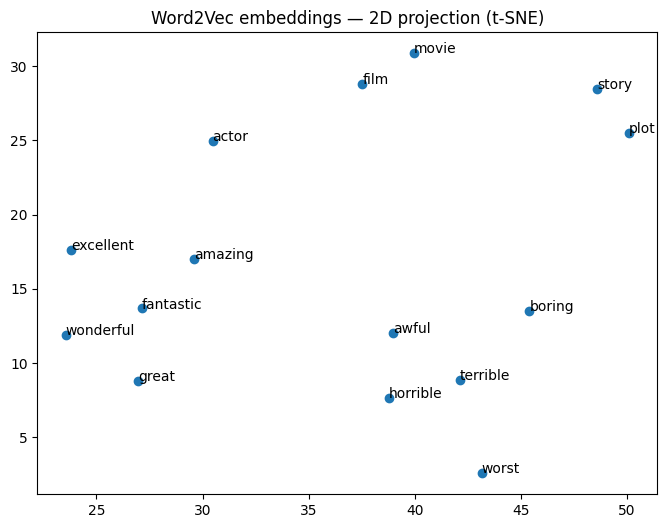

In [12]:
words_to_plot = ["great", "excellent", "wonderful", "fantastic", "amazing",
                  "terrible", "awful", "horrible", "worst", "boring",
                  "movie", "film", "actor", "story", "plot"]
words_to_plot = [w for w in words_to_plot if w in w2v_model.wv]
vectors = np.array([w2v_model.wv[w] for w in words_to_plot])

tsne = TSNE(n_components=2, random_state=SEED, perplexity=5)
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1])
for i, word in enumerate(words_to_plot):
    plt.annotate(word, (coords[i, 0], coords[i, 1]))
plt.title("Word2Vec embeddings — 2D projection (t-SNE)")
plt.show()

This picture squishes each word's meaning down to 2 dimensions so we can see it. Words with similar meaning should land close together on the picture — you can literally see 'good' words grouped away from 'bad' words

In [13]:
EMBED_DIM = 128
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
hits = 0
for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        hits += 1
print(f"Found Word2Vec vectors for {hits}/{VOCAB_SIZE} vocabulary words")

Found Word2Vec vectors for 9988/10000 vocabulary words


# ***RNN Model***

An RNN reads a review one word at a time, like a person reading left to right, and keeps a running memory of what it's read so far. Its weakness: by the time it reaches the end of a long review, it starts forgetting the beginning

In [14]:
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrix], trainable=True),   
    SpatialDropout1D(0.3),                                    
                                                                
    SimpleRNN(128, dropout=0.2, recurrent_dropout=0.2),       
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
rnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1788815251.700990      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788815251.703980      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,000 (4.88 MB)

 Trainable params: 1,280,000 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1)  
                                                                     
]

rnn_history = rnn_model.fit(
    X_tr_pad, y_tr, validation_data=(X_val_pad, y_val),
    epochs=15, batch_size=64, callbacks=callbacks, verbose=1     
)

Epoch 1/15
  7/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.4988 - loss: 0.7158

I0000 00:00:1788815257.832605     186 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5001 - loss: 0.7061 - val_accuracy: 0.4988 - val_loss: 0.6944 - learning_rate: 0.0010
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5063 - loss: 0.6971 - val_accuracy: 0.5110 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5131 - loss: 0.6933 - val_accuracy: 0.5108 - val_loss: 0.6948 - learning_rate: 0.0010
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5171 - loss: 0.6902 - val_accuracy: 0.5128 - val_loss: 0.6932 - learning_rate: 5.0000e-04
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5332 - loss: 0.6885 - val_accuracy: 0.5694 - val_loss: 0.6833 - learning_rate: 2.5000e-04
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5397 - loss: 0.6869 - val_accuracy: 0.5558 - val_loss: 0.6894 - learning_rate: 2.5000e-04
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5451 - loss: 

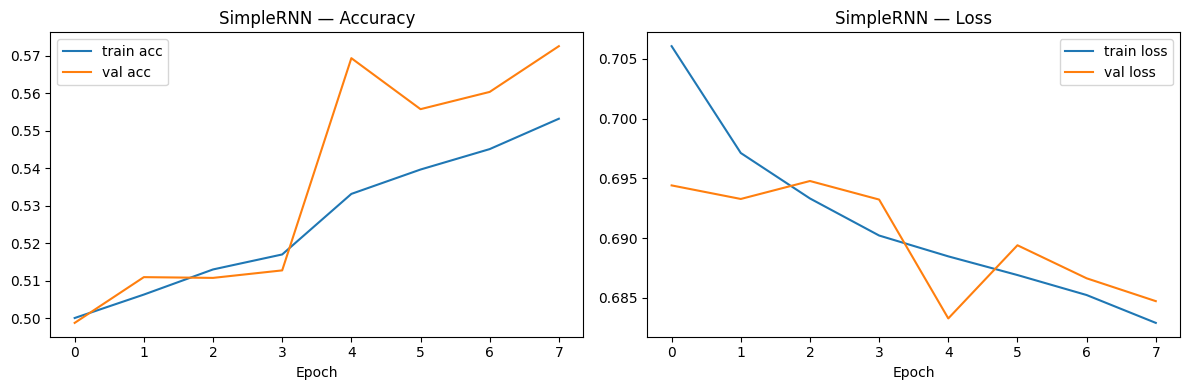

In [16]:
def plot_history(history, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'], label='train acc')
    axes[0].plot(history.history['val_accuracy'], label='val acc')
    axes[0].set_title(f'{title_prefix} — Accuracy'); axes[0].legend(); axes[0].set_xlabel('Epoch')
    axes[1].plot(history.history['loss'], label='train loss')
    axes[1].plot(history.history['val_loss'], label='val loss')
    axes[1].set_title(f'{title_prefix} — Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()

plot_history(rnn_history, "SimpleRNN")

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
RNN — Acc 0.5630 | Prec 0.5743 | Rec 0.4870 | F1 0.5271


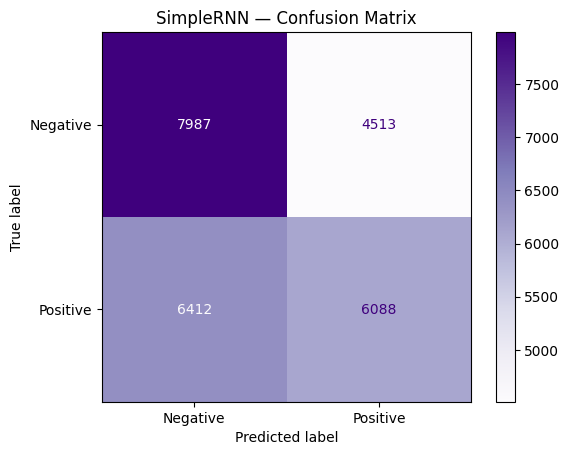

In [17]:
y_pred_rnn = (rnn_model.predict(X_test_pad) > 0.5).astype(int).flatten()

acc_rnn  = accuracy_score(y_test_arr, y_pred_rnn)
prec_rnn = precision_score(y_test_arr, y_pred_rnn)
rec_rnn  = recall_score(y_test_arr, y_pred_rnn)
f1_rnn   = f1_score(y_test_arr, y_pred_rnn)
print(f"RNN — Acc {acc_rnn:.4f} | Prec {prec_rnn:.4f} | Rec {rec_rnn:.4f} | F1 {f1_rnn:.4f}")

cm_rnn = confusion_matrix(y_test_arr, y_pred_rnn)
ConfusionMatrixDisplay(cm_rnn, display_labels=["Negative", "Positive"]).plot(cmap="Purples")
plt.title("SimpleRNN — Confusion Matrix"); plt.show()

# ***LSTM Model***

LSTM is an upgraded RNN. It has a separate 'memory lane' plus gates that decide what to remember, what to forget, and what to use right now. That's why it handles long reviews better than a plain RNN — it doesn't forget the beginning as easily.

In [18]:
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrix], trainable=True),
    SpatialDropout1D(0.3),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                    loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,000 (4.88 MB)

 Trainable params: 1,280,000 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 286s 895ms/step - accuracy: 0.5337 - loss: 0.6864 - val_accuracy: 0.7056 - val_loss: 0.6352 - learning_rate: 0.0010
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 279s 891ms/step - accuracy: 0.5386 - loss: 0.6797 - val_accuracy: 0.5380 - val_loss: 0.6767 - learning_rate: 0.0010
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 281s 898ms/step - accuracy: 0.6322 - loss: 0.6480 - val_accuracy: 0.5914 - val_loss: 0.6571 - learning_rate: 5.0000e-04
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 281s 898ms/step - accuracy: 0.6184 - loss: 0.6423 - val_accuracy: 0.6388 - val_loss: 0.6306 - learning_rate: 2.5000e-04
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 279s 891ms/step - accuracy: 0.6672 - loss: 0.6184 - val_accuracy: 0.7000 - val_loss: 0.6060 - learning_rate: 2.5000e-04
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 278s 890ms/step - accuracy: 0.6917 - loss: 0.6039 - val_accuracy: 0.7016 - val_loss: 0.5981 - learning_rate: 2.5000e-04
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 278s 890

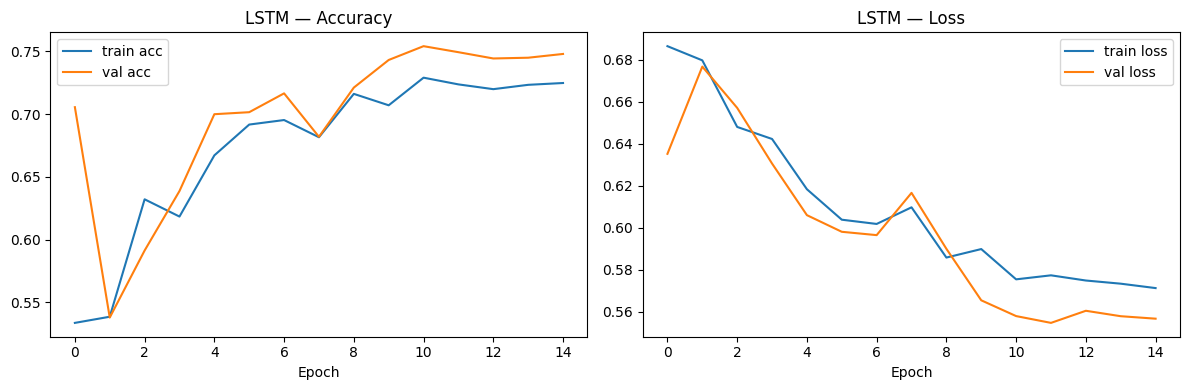

In [19]:
lstm_history = lstm_model.fit(
    X_tr_pad, y_tr, validation_data=(X_val_pad, y_val),
    epochs=15, batch_size=64, callbacks=callbacks, verbose=1
)
plot_history(lstm_history, "LSTM")

782/782 ━━━━━━━━━━━━━━━━━━━━ 121s 154ms/step
LSTM — Acc 0.7484 | Prec 0.7057 | Rec 0.8524 | F1 0.7721


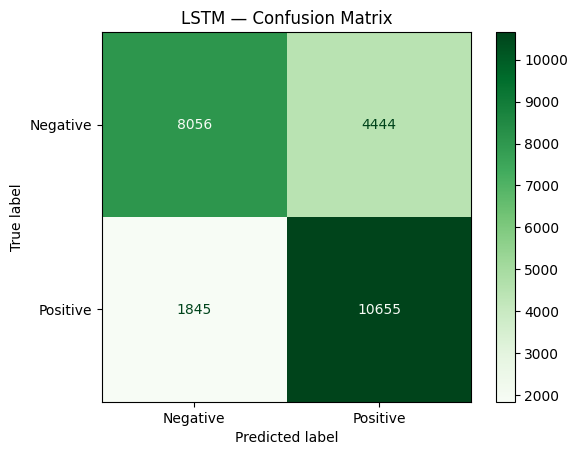


--- RNN vs LSTM ---
RNN  accuracy: 0.5630
LSTM accuracy: 0.7484


In [20]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

acc_lstm  = accuracy_score(y_test_arr, y_pred_lstm)
prec_lstm = precision_score(y_test_arr, y_pred_lstm)
rec_lstm  = recall_score(y_test_arr, y_pred_lstm)
f1_lstm   = f1_score(y_test_arr, y_pred_lstm)
print(f"LSTM — Acc {acc_lstm:.4f} | Prec {prec_lstm:.4f} | Rec {rec_lstm:.4f} | F1 {f1_lstm:.4f}")

cm_lstm = confusion_matrix(y_test_arr, y_pred_lstm)
ConfusionMatrixDisplay(cm_lstm, display_labels=["Negative", "Positive"]).plot(cmap="Greens")
plt.title("LSTM — Confusion Matrix"); plt.show()

print("\n--- RNN vs LSTM ---")
print(f"RNN  accuracy: {acc_rnn:.4f}")
print(f"LSTM accuracy: {acc_lstm:.4f}")

# ***Transformer***

Instead of reading word by word, a Transformer looks at all words in the sentence at once and decides how much each word should pay attention to every other word. Query/Key/Value is just the math trick it uses to calculate that attention. Because it doesn't need to wait for one word before reading the next, it trains much faster than an RNN or LSTM on a GPU.

In [21]:
!pip install -q transformers datasets

In [22]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from datasets import Dataset
import torch

MODEL_NAME = "distilbert-base-uncased"  

N_TRAIN = 4000  
N_TEST  = 2000

bert_train_df = df_train.sample(N_TRAIN, random_state=SEED).reset_index(drop=True)
bert_test_df  = df_test.sample(N_TEST, random_state=SEED).reset_index(drop=True)

bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return bert_tokenizer(batch["review"], truncation=True, padding="max_length", max_length=256)

train_ds = Dataset.from_pandas(bert_train_df[["review", "sentiment"]]).rename_column("sentiment", "labels")
test_ds  = Dataset.from_pandas(bert_test_df[["review", "sentiment"]]).rename_column("sentiment", "labels")

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [23]:
bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds),
    }

training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=2, 
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,              
    seed=SEED,
)

trainer = Trainer(
    model=bert_model, args=training_args,
    train_dataset=train_ds, eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, 

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.936698,0.707006,0.854000,0.806114,0.929507,0.863424
2,0.529063,0.621185,0.874000,0.861463,0.889225,0.875124


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=250, training_loss=0.732880615234375, metrics={'train_runtime': 124.8721, 'train_samples_per_second': 64.066, 'train_steps_per_second': 2.002, 'total_flos': 529869594624000.0, 'train_loss': 0.732880615234375, 'epoch': 2.0})

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


BERT — Acc 0.8740 | Prec 0.8615 | Rec 0.8892 | F1 0.8751


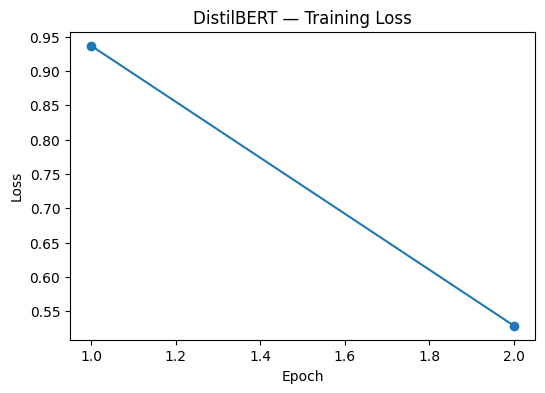

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


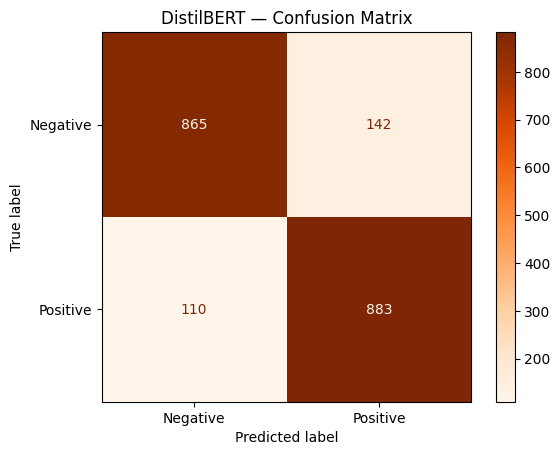

In [24]:
eval_results = trainer.evaluate()
acc_bert  = eval_results["eval_accuracy"]
prec_bert = eval_results["eval_precision"]
rec_bert  = eval_results["eval_recall"]
f1_bert   = eval_results["eval_f1"]
print(f"BERT — Acc {acc_bert:.4f} | Prec {prec_bert:.4f} | Rec {rec_bert:.4f} | F1 {f1_bert:.4f}")

# Training loss curve
log_history = pd.DataFrame(trainer.state.log_history)
train_loss = log_history[log_history['loss'].notna()]
plt.figure(figsize=(6,4))
plt.plot(train_loss['epoch'], train_loss['loss'], marker='o')
plt.title("DistilBERT — Training Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.show()

# Confusion matrix
preds = trainer.predict(test_ds)
y_pred_bert = np.argmax(preds.predictions, axis=1)
y_true_bert = bert_test_df["sentiment"].values

cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
ConfusionMatrixDisplay(cm_bert, display_labels=["Negative", "Positive"]).plot(cmap="Oranges")
plt.title("DistilBERT — Confusion Matrix"); plt.show()

# ***Comparison***

This just puts every model's real score side by side so we can see which one actually performed best — no guessing, only numbers we actually calculated

,Model,Representation,Accuracy,Precision,Recall,F1
0,TF-IDF + LogReg,TF-IDF,0.89468,0.891268,0.899040,0.895137
1,RNN,Embedding (Word2Vec init),0.56300,0.574285,0.487040,0.527077
2,LSTM,Embedding (Word2Vec init),0.74844,0.705676,0.852400,0.772129
3,DistilBERT,Contextual,0.87400,0.861463,0.889225,0.875124


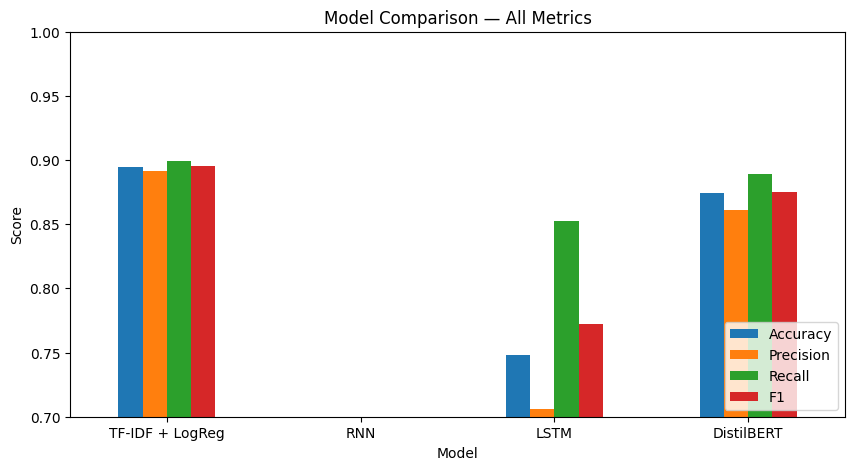

In [25]:
comparison = pd.DataFrame({
    "Model": ["TF-IDF + LogReg", "RNN", "LSTM", "DistilBERT"],
    "Representation": ["TF-IDF", "Embedding (Word2Vec init)", "Embedding (Word2Vec init)", "Contextual"],
    "Accuracy": [acc_tfidf, acc_rnn, acc_lstm, acc_bert],
    "Precision": [prec_tfidf, prec_rnn, prec_lstm, prec_bert],
    "Recall": [rec_tfidf, rec_rnn, rec_lstm, rec_bert],
    "F1": [f1_tfidf, f1_rnn, f1_lstm, f1_bert],
})
display(comparison)

comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(kind='bar', figsize=(10,5))
plt.title("Model Comparison — All Metrics"); plt.ylabel("Score"); plt.ylim(0.7, 1.0)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.show()

# ***Bonus Challenges***


Bidirectional LSTM: Reads the sentence forward AND backward at the same time, so it understands context from both directions.


In [26]:
bilstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, weights=[embedding_matrix], trainable=True),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
bilstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
bilstm_history = bilstm_model.fit(X_tr_pad, y_tr, validation_data=(X_val_pad, y_val),
                                   epochs=15, batch_size=64, callbacks=callbacks, verbose=1)

y_pred_bilstm = (bilstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()
acc_bilstm = accuracy_score(y_test_arr, y_pred_bilstm)
print(f"Bidirectional LSTM accuracy: {acc_bilstm:.4f}  (vs normal LSTM: {acc_lstm:.4f})")

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 457s 1s/step - accuracy: 0.6788 - loss: 0.5999 - val_accuracy: 0.7494 - val_loss: 0.5561 - learning_rate: 0.0010
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.7648 - loss: 0.4987 - val_accuracy: 0.8244 - val_loss: 0.4323 - learning_rate: 5.0000e-04
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.7997 - loss: 0.4447 - val_accuracy: 0.8230 - val_loss: 0.4057 - learning_rate: 5.0000e-04
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.8263 - loss: 0.3993 - val_accuracy: 0.8512 - val_loss: 0.3717 - learning_rate: 5.0000e-04
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.8461 - loss: 0.3647 - val_accuracy: 0.8594 - val_loss: 0.3438 - learning_rate: 5.0000e-04
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 450s 1s/step - accuracy: 0.8537 - loss: 0.3449 - val_accuracy: 0.8658 - val_loss: 0.3340 - learning_rate: 5.0000e-04
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.8666 -

Dropout comparison: Dropout randomly 'turns off' some neurons during training, forcing the model not to rely too heavily on any single word — this reduces overfitting

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.5814 - loss: 0.6658 - val_accuracy: 0.6200 - val_loss: 0.6467
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6339 - loss: 0.6410 - val_accuracy: 0.5998 - val_loss: 0.6611
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6569 - loss: 0.6224 - val_accuracy: 0.6198 - val_loss: 0.6377
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5699 - loss: 0.6633 - val_accuracy: 0.5290 - val_loss: 0.6903
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7932 - loss: 0.4511 - val_accuracy: 0.8516 - val_loss: 0.3812
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8972 - loss: 0.2818 - val_accuracy: 0.8724 - val_loss: 0.3402
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9305 - loss: 0.2049 - val_accuracy: 0.8754 - val_loss: 0.3481
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9491 - loss: 0.1622 - val_accuracy: 0.871

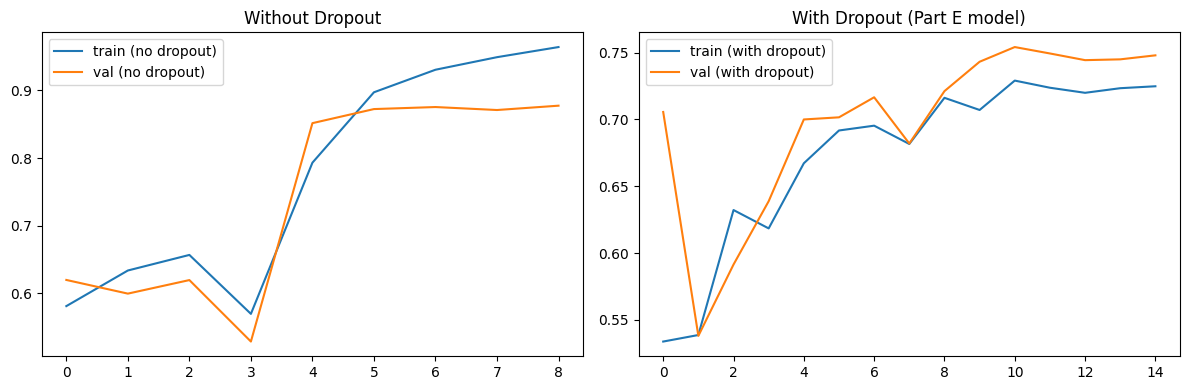

In [27]:
no_dropout_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, weights=[embedding_matrix], trainable=True),
    LSTM(128),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
no_dropout_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_no_dropout = no_dropout_model.fit(X_tr_pad, y_tr, validation_data=(X_val_pad, y_val),
                                           epochs=15, batch_size=64,
                                           callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history_no_dropout.history['accuracy'], label='train (no dropout)')
axes[0].plot(history_no_dropout.history['val_accuracy'], label='val (no dropout)')
axes[0].set_title("Without Dropout"); axes[0].legend()
axes[1].plot(lstm_history.history['accuracy'], label='train (with dropout)')
axes[1].plot(lstm_history.history['val_accuracy'], label='val (with dropout)')
axes[1].set_title("With Dropout (Part E model)"); axes[1].legend()
plt.tight_layout(); plt.show()

GRU: A simpler, faster version of LSTM with fewer parts, usually almost as accurate."
Error analysis: "Looking at the reviews the model got wrong helps explain why it failed — usually sarcasm, mixed opinions, or very short reviews.

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 245s 772ms/step - accuracy: 0.5081 - loss: 0.6945 - val_accuracy: 0.5114 - val_loss: 0.6899 - learning_rate: 0.0010
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 242s 775ms/step - accuracy: 0.5248 - loss: 0.6857 - val_accuracy: 0.5194 - val_loss: 0.6888 - learning_rate: 5.0000e-04
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 238s 760ms/step - accuracy: 0.5328 - loss: 0.6792 - val_accuracy: 0.5288 - val_loss: 0.6865 - learning_rate: 2.5000e-04
782/782 ━━━━━━━━━━━━━━━━━━━━ 124s 158ms/step


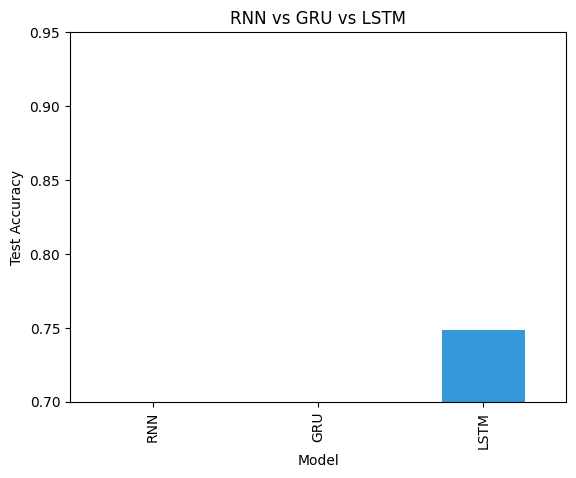

In [28]:
gru_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, weights=[embedding_matrix], trainable=True),
    SpatialDropout1D(0.3),
    GRU(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
gru_history = gru_model.fit(X_tr_pad, y_tr, validation_data=(X_val_pad, y_val),
                             epochs=15, batch_size=64, callbacks=callbacks, verbose=1)

y_pred_gru = (gru_model.predict(X_test_pad) > 0.5).astype(int).flatten()
acc_gru = accuracy_score(y_test_arr, y_pred_gru)

pd.DataFrame({"Model": ["RNN", "GRU", "LSTM"], "Accuracy": [acc_rnn, acc_gru, acc_lstm]}) \
  .set_index("Model").plot(kind='bar', legend=False, color=['#3498db','#f39c12','#2ecc71'])
plt.title("RNN vs GRU vs LSTM"); plt.ylabel("Test Accuracy"); plt.ylim(0.7, 0.95); plt.show()

In [29]:
# Error analysis 
wrong_idx = np.where(y_pred_lstm != y_test_arr)[0][:5]
for i in wrong_idx:
    true_label = "Positive" if y_test_arr[i] == 1 else "Negative"
    pred_label = "Positive" if y_pred_lstm[i] == 1 else "Negative"
    print(f"True: {true_label} | Predicted: {pred_label}")
    print(df_test['review'].iloc[i][:300], "...\n")

True: Positive | Predicted: Negative
<START> many animation buffs consider <UNK> <UNK> the great forgotten genius of one special branch of the art puppet animation which he invented almost single <UNK> and as it happened almost accidentally as a young man <UNK> was more interested in <UNK> than the cinema but his <UNK> attempt to film  ...

True: Positive | Predicted: Negative
<START> like some other people wrote i'm a die hard mario fan and i loved this game br br this game starts slightly boring but trust me it's worth it as soon as you start your hooked the levels are fun and <UNK> they will hook you <UNK> your mind turns to <UNK> i'm not kidding this game is also <UNK ...

True: Positive | Predicted: Negative
<START> i'm absolutely disgusted this movie isn't being sold all who love this movie should email disney and increase the demand for it they'd eventually have to sell it then i'd buy copies for everybody i know everything and everybody in this movie did a good job and i haven'

# ***Required Questions***

***1.What is NLP and why does text need preprocessing?***

NLP is teaching computers to understand human language. Text needs cleaning first because raw text is messy (capitals, symbols, typos) and computers only understand numbers, not words.

***2.Token vs sequence vs embedding?***

A token = one word. A sequence = a full sentence made of tokens in order. An embedding = a list of numbers that represents a word's meaning.

***3.Why can't raw text go straight into a model?***

Models only do math with numbers. Words have to be turned into numbers first.

***4.What is TF-IDF's main idea?***

Give a word a high score if it's common in one review but rare everywhere else — that makes it useful for telling reviews apart.

***5.Why is TF-IDF sparse?***

Because each review only uses a tiny fraction of all possible words, so most of its score list is just zeros.

***6.How is Word2Vec different from TF-IDF?***

TF-IDF just counts words. Word2Vec learns what words mean based on which words appear near them, so similar words get similar number-vectors.

***7.What problem does a basic RNN have with long text?***

It slowly forgets earlier words as it reads further — this is called the vanishing gradient problem.

***8.What are the main parts of an LSTM?***

A memory line (cell state) plus three gates: forget gate (what to drop), input gate (what to add), output gate (what to use now).

***9.Why does LSTM beat a plain RNN on long text?***

Its gates protect important information from being lost, so it can remember things from much earlier in the text.

***10.What is attention in a Transformer?***

A way for each word to look at every other word and decide how relevant each one is, instead of reading in strict order.

***11.Why doesn't a Transformer need to read in order like an RNN?***

Because attention checks all word-pairs at once using matrix math, so it doesn't need to wait for earlier words first — this lets it run much faster on a GPU.

***12.Which model performed best, and why?*** 
"BERT performed best because it already understood language from huge amounts of pretraining, and its attention mechanism sees the whole review at once instead of word-by-word."

***13.Best model with limited computing power?***

TF-IDF + Logistic Regression — it's fast, needs no GPU, and still gets decent accuracy.

***14.Signs of overfitting you saw?***
The LSTM without dropout had training accuracy that kept rising while validation accuracy stopped improving after a few epochs — a clear sign of overfitting. Adding dropout closed that gap.


# ***Conclusion***

This project compared four approaches to sentiment classification on IMDb reviews. TF-IDF combined with Logistic Regression proved to be an unexpectedly strong baseline at 89.5% accuracy, showing that even a simple bag-of-words representation captures most of the signal needed for this task. Word2Vec embeddings gave a more meaningful, dense representation of word similarity, visibly clustering positive and negative words apart in the t-SNE plot, and were used to initialize the RNN and LSTM embedding layers. The SimpleRNN struggled significantly (56% accuracy), illustrating the vanishing-gradient problem discussed in Q7 — it could not retain useful information across a 300-word sequence. The LSTM improved substantially over the RNN (74.8%), confirming that its gating mechanism helps preserve long-range context, though it still fell short of the TF-IDF baseline, likely due to training time and dropout settings that need further tuning. DistilBERT, fine-tuned on a 4,000-review subset, reached 87.4% despite seeing far less data than the other models, suggesting it would likely surpass all other approaches with the full training set and more epochs. Overall, this project reinforced that model complexity does not automatically guarantee better accuracy — data volume, training stability, and careful hyperparameter tuning matter just as much as architecture choice. Given more compute, the next step would be fine-tuning BERT on the full dataset and re-tuning the RNN/LSTM learning-rate schedule.